In [10]:
pip install shap

# **IMPORT THE NECESSARY LIBRARIES**

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

# **LOAD THE DATASET**

In [12]:
data = pd.read_csv("Normal &Malicious SQLi.csv")

data.head(5)

,Query,Type Attack,query_length,word_count,special_char_count,digit_count,contains_select,contains_union,contains_insert,contains_update,...,contains_single_quote,contains_double_quote,contains_equals,contains_sleep,max_word_length,min_word_length,uppercase_count,special_char_ratio,Query_Entropy,Query_Digit_Ratio
0,mmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmm...,Malicious,110,5,1,2,0,0,0,0,...,0,0,1,0,102,1,0,0.009091,1.482333,0.018182
1,xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx...,Malicious,725,26,4,43,1,0,0,0,...,0,0,1,0,589,1,0,0.005517,2.203815,0.059310
2,"-3865"" ) where 3559 = 3559 union all select 3...",Malicious,81,10,5,40,1,1,0,0,...,0,1,1,0,36,1,0,0.061728,3.738639,0.493827
3,1' ) ) ) or sleep ( 5 ) and ...,Malicious,78,16,4,2,0,0,0,0,...,1,0,0,1,6,1,0,0.051282,2.849670,0.025641
4,"1"" ) as gdcx where 2335 = 2335 and 6969 = ( ...",Malicious,589,92,16,18,1,0,0,0,...,1,1,1,1,17,1,16,0.027165,4.651835,0.030560


# **CHECK THE COLUMN NAME**

In [13]:
print(data.columns)

Index(['Query', 'Type Attack', 'query_length', 'word_count',
       'special_char_count', 'digit_count', 'contains_select',
       'contains_union', 'contains_insert', 'contains_update',
       'contains_delete', 'contains_where', 'contains_and', 'contains_or',
       'keyword_ratio', 'contains_double_dash', 'contains_comment',
       'contains_semicolon', 'contains_single_quote', 'contains_double_quote',
       'contains_equals', 'contains_sleep', 'max_word_length',
       'min_word_length', 'uppercase_count', 'special_char_ratio',
       'Query_Entropy', 'Query_Digit_Ratio'],
      dtype='object')


# **DATA INFORMATION**

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64172 entries, 0 to 64171
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Query                  64172 non-null  object 
 1   Type Attack            64172 non-null  object 
 2   query_length           64172 non-null  int64  
 3   word_count             64172 non-null  int64  
 4   special_char_count     64172 non-null  int64  
 5   digit_count            64172 non-null  int64  
 6   contains_select        64172 non-null  int64  
 7   contains_union         64172 non-null  int64  
 8   contains_insert        64172 non-null  int64  
 9   contains_update        64172 non-null  int64  
 10  contains_delete        64172 non-null  int64  
 11  contains_where         64172 non-null  int64  
 12  contains_and           64172 non-null  int64  
 13  contains_or            64172 non-null  int64  
 14  keyword_ratio          64172 non-null  float64
 15  co

# **CHECKING THE MISSING VALUES**

In [15]:
data.isnull().sum()

,0
Query,0
Type Attack,0
query_length,0
word_count,0
special_char_count,0
digit_count,0
contains_select,0
contains_union,0
contains_insert,0
contains_update,0


# **DESCRIBTIVE STATISTIC**

In [16]:
data.describe()

,query_length,word_count,special_char_count,digit_count,contains_select,contains_union,contains_insert,contains_update,contains_delete,contains_where,...,contains_single_quote,contains_double_quote,contains_equals,contains_sleep,max_word_length,min_word_length,uppercase_count,special_char_ratio,Query_Entropy,Query_Digit_Ratio
count,64172.000000,64172.000000,64172.000000,64172.000000,64172.000000,64172.000000,64172.000000,64172.000000,64172.000000,64172.000000,...,64172.000000,64172.000000,64172.000000,64172.000000,64172.00000,64172.000000,64172.000000,64172.000000,64172.000000,64172.000000
mean,135.305975,18.388347,4.745278,20.481581,0.674375,0.139734,0.007215,0.011859,0.007682,0.321449,...,0.380103,0.193776,0.567039,0.067537,33.65005,2.162438,6.755672,0.042143,3.964957,0.151634
std,185.933331,22.073187,8.732349,51.264127,0.468612,0.346713,0.084635,0.108251,0.087313,0.467036,...,0.485416,0.395259,0.495489,0.250952,90.60439,8.079073,13.260662,0.045413,0.831113,0.199276
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,41.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,7.00000,1.000000,0.000000,0.006369,3.646428,0.000000
50%,68.000000,12.000000,4.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,11.00000,1.000000,0.000000,0.031250,4.136842,0.097561
75%,139.000000,21.000000,6.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,0.000000,19.00000,1.000000,15.000000,0.064516,4.439949,0.210526
max,5370.000000,254.000000,168.000000,961.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,987.00000,978.000000,1544.000000,1.000000,6.221005,1.000000


# **Attack Distribution**

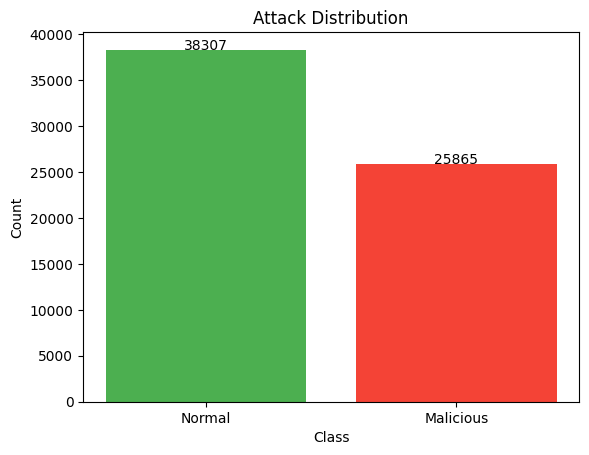

In [61]:
attack_counts = data['Type Attack'].value_counts()

plt.figure()

# Assign different colors
colors = ['#4CAF50', '#F44336']

plt.bar(['Normal', 'Malicious'], attack_counts, color=colors)

plt.title("Attack Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

# Show values on top
for i, v in enumerate(attack_counts):
    plt.text(i, v, str(v), ha='center')

plt.show()

# **Query Length Trend**

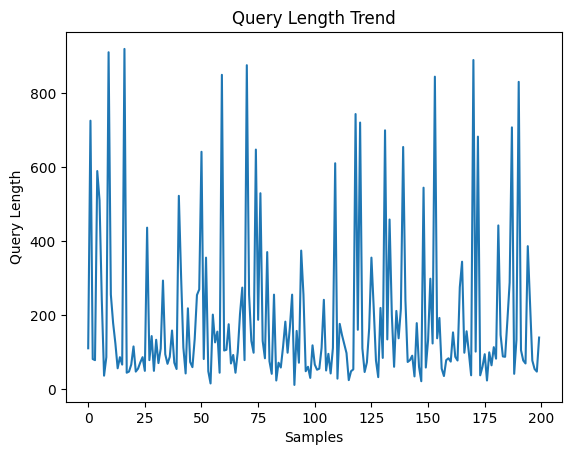

In [54]:
plt.figure()

# Example: query_length trend
plt.plot(data['query_length'][:200])

plt.title("Query Length Trend")
plt.xlabel("Samples")
plt.ylabel("Query Length")

plt.show()

# **HEAT MAP**

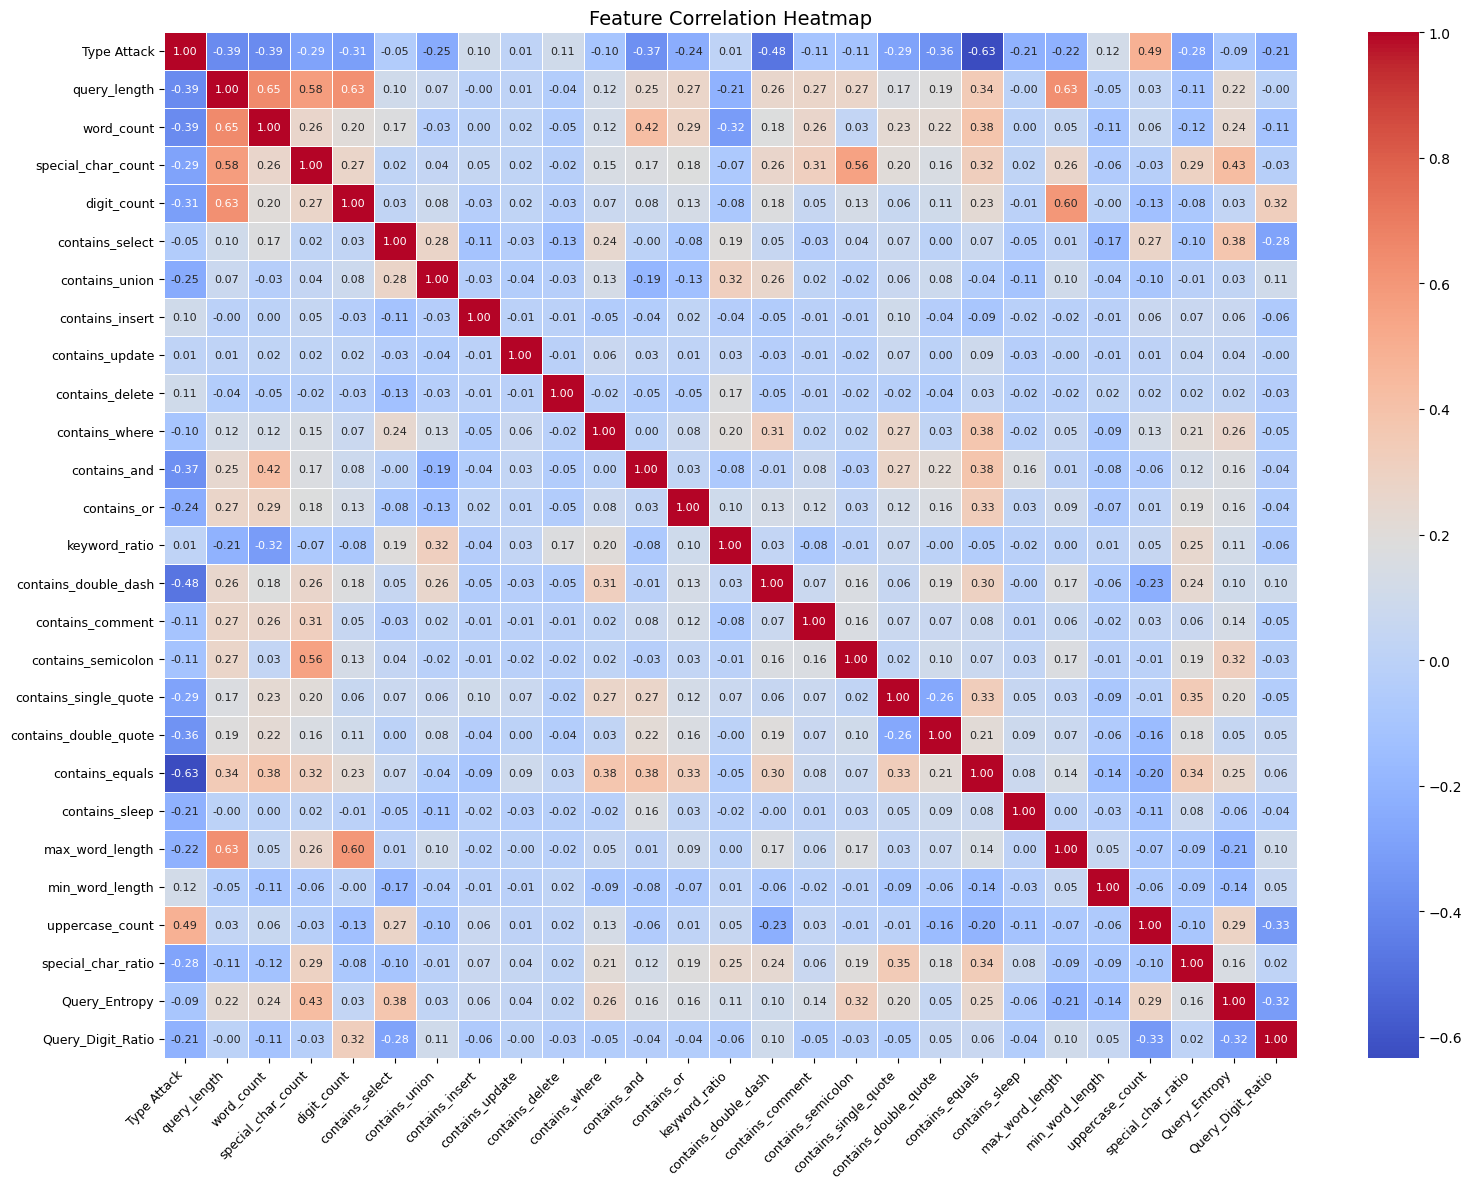

In [62]:
plt.figure(figsize=(16,12))

corr = data.drop(['Query'], axis=1).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap='coolwarm',
    cbar=True,
    annot_kws={"size": 8}
)


plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title("Feature Correlation Heatmap", fontsize=14)

plt.tight_layout()
plt.show()

# **LEVEL ENCODER**

In [17]:
le = LabelEncoder()
data['Type Attack'] = le.fit_transform(data['Type Attack'])

print("Labels after encoding:", data['Type Attack'].unique())

Labels after encoding: [0 1]


# **TARGET VARIABLES**

In [18]:
X = data.drop(['Query', 'Type Attack'], axis=1)
y = data['Type Attack']

# **NORMALIZATION**

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **TRAIN-TEST SPLIT**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# **MACHINE LEARNING MODELS**

# **`LOGISTIC REGRESSION RESULTS`**

In [69]:
# ================= LOGISTIC REGRESSION =================

lr = LogisticRegression(
    max_iter=1000,
    C=0.5,
    penalty='l2',
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Evaluation function (FIXED)
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

print("\n========== LOGISTIC REGRESSION RESULTS ==========\n")

print("🔹 Logistic Regression Performance")

# Metrics (rounded properly)
metrics = evaluate(y_test, lr_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

# Classification Report (MATCH PRECISION)
from sklearn.metrics import classification_report

print("\nLogistic Regression Classification Report:\n")
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Normal", "Malicious"],
    digits=4
))

print("--------------------------------------------------\n")


========== LOGISTIC REGRESSION RESULTS ==========

🔹 Logistic Regression Performance
Accuracy: 0.9905
Precision: 0.9819
Recall: 0.9950
F1 Score: 0.9884

Logistic Regression Classification Report:

              precision    recall  f1-score   support

      Normal     0.9966    0.9874    0.9920      7613
   Malicious     0.9819    0.9950    0.9884      5222

    accuracy                         0.9905     12835
   macro avg     0.9892    0.9912    0.9902     12835
weighted avg     0.9906    0.9905    0.9905     12835

--------------------------------------------------



# **`CONFUCION MATRIX OF LOGISTIC REGRESSION`**

<Figure size 640x480 with 0 Axes>

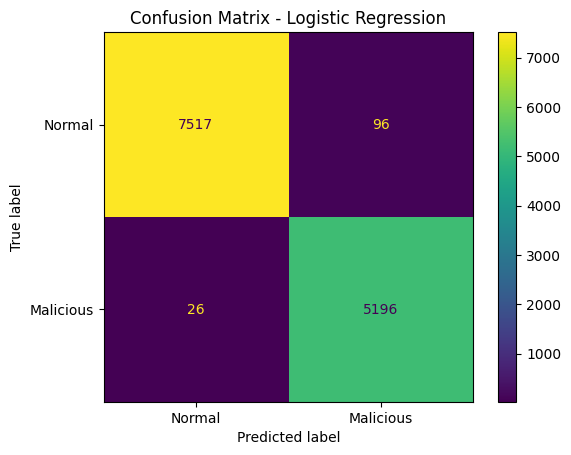

In [22]:
cm_lr = confusion_matrix(y_test, lr_pred)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Normal", "Malicious"])

plt.figure()
disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# **`RANDOM FOREST RESULTS`**

In [23]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("========== RANDOM FOREST RESULTS ==========\n")

print(" Random Forest Performance")

metrics = evaluate(y_test, rf_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

print("\n Random Forest Classification Report:\n")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Normal", "Malicious"],
    zero_division=0,
    digits=4
))

print("--------------------------------------------------\n")

========== RANDOM FOREST RESULTS ==========

🔹 Random Forest Performance
Accuracy: 0.9980
Precision: 0.9985
Recall: 0.9966
F1 Score: 0.9975

 Random Forest Classification Report:

              precision    recall  f1-score   support

      Normal     0.9976    0.9989    0.9983      7613
   Malicious     0.9985    0.9966    0.9975      5222

    accuracy                         0.9980     12835
   macro avg     0.9981    0.9978    0.9979     12835
weighted avg     0.9980    0.9980    0.9980     12835

--------------------------------------------------



# **`CONFUCION MATRIX OF RANDOM FOREST`**

<Figure size 640x480 with 0 Axes>

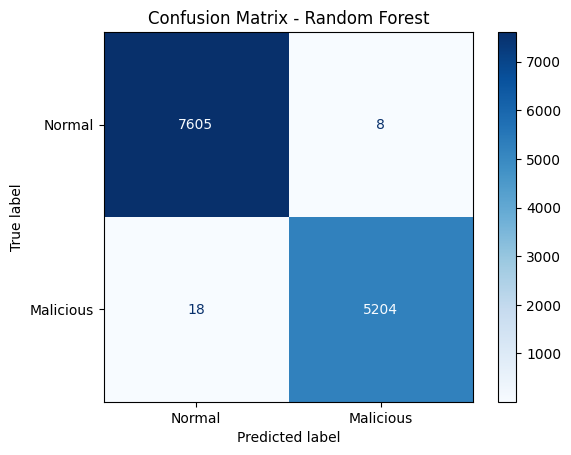

In [24]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "Malicious"]
)

plt.figure()
disp_rf.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# **`SVM RESULTS`**

In [25]:
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print("========== SVM RESULTS ==========\n")

print("🔹 SVM Performance")

# Metrics
metrics = evaluate(y_test, svm_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

# Classification Report
print("\nSVM Classification Report:\n")
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Normal", "Malicious"],
    zero_division=0,
    digits=4
))

print("--------------------------------------------------\n")

========== SVM RESULTS ==========

🔹 SVM Performance
Accuracy: 0.9979
Precision: 0.9975
Recall: 0.9973
F1 Score: 0.9974

SVM Classification Report:

              precision    recall  f1-score   support

      Normal     0.9982    0.9983    0.9982      7613
   Malicious     0.9975    0.9973    0.9974      5222

    accuracy                         0.9979     12835
   macro avg     0.9978    0.9978    0.9978     12835
weighted avg     0.9979    0.9979    0.9979     12835

--------------------------------------------------



# **`CONFUCION MATRIX OF SVM`**

<Figure size 640x480 with 0 Axes>

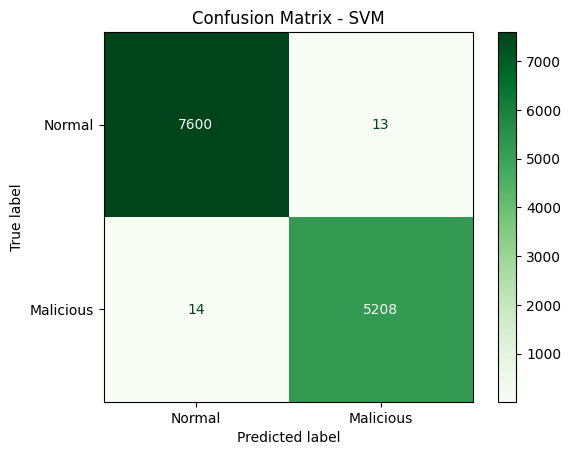

In [26]:
cm_svm = confusion_matrix(y_test, svm_pred)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Normal", "Malicious"]
)

plt.figure()
disp_svm.plot(cmap='Greens')
plt.title("Confusion Matrix - SVM")
plt.show()

# **`MODEL COMPRESION`**

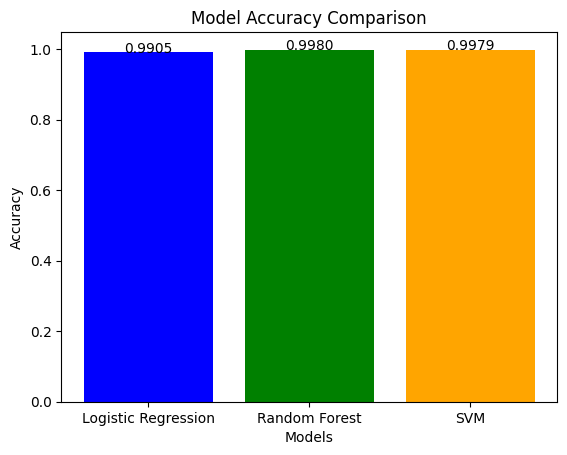

In [27]:
models = ['Logistic Regression', 'Random Forest', 'SVM']

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, svm_pred)
]

f1_scores = [
    f1_score(y_test, lr_pred),
    f1_score(y_test, rf_pred),
    f1_score(y_test, svm_pred)
]

# ---------------- Accuracy Chart ----------------
plt.figure()
plt.bar(models, accuracy, color=['blue', 'green', 'orange'])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracy):
    plt.text(i, v, f"{v:.4f}", ha='center')

plt.show()

# **`CROSS VALIDATION`**

In [28]:
rf_scores = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("K-Fold Scores:", rf_scores)
print("Mean Accuracy:", rf_scores.mean())
print("Standard Deviation:", rf_scores.std())

K-Fold Scores: [0.99711726 0.99820802 0.99766246 0.99797413 0.99750662]
Mean Accuracy: 0.9976936991540839
Standard Deviation: 0.0003772085747169564


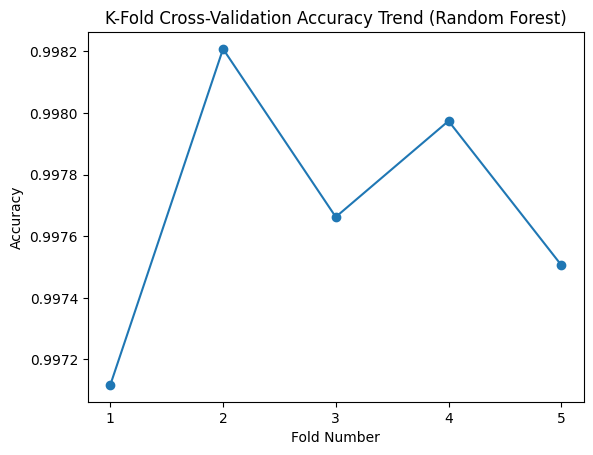

In [29]:
folds = list(range(1, len(rf_scores) + 1))

plt.figure()
plt.plot(folds, rf_scores, marker='o')

plt.title("K-Fold Cross-Validation Accuracy Trend (Random Forest)")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")

plt.xticks(folds)

plt.show()

# **`SHAP EXPLAINABILITY`**


========== SHAP EXPLAINABILITY (RANDOM FOREST) ==========

🔹 SHAP Feature Importance (Bar Plot)


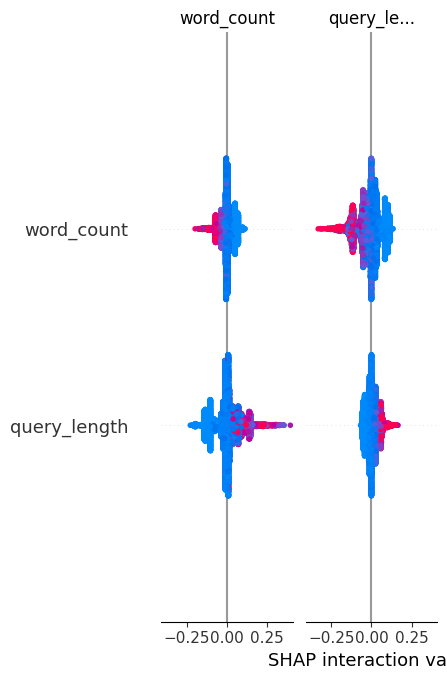

🔹 SHAP Detailed Feature Impact


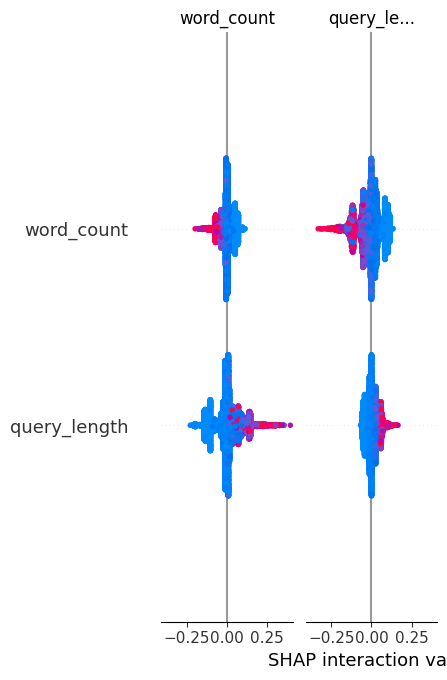

In [43]:
# ================= SHAP (ROBUST FIX) =================
import shap
import pandas as pd
import numpy as np

print("\n========== SHAP EXPLAINABILITY (RANDOM FOREST) ==========\n")

# 1) Ensure DataFrame with correct columns (same as training)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# (Optional but safe) If your model was trained on scaled features, keep using the same scaled X_test.
# We are already using X_test (scaled), so this is consistent.

# 2) Use TreeExplainer (best for RF)
explainer = shap.TreeExplainer(rf)

# 3) Compute SHAP values (disable strict additivity check)
shap_values = explainer.shap_values(X_test_df, check_additivity=False)

# 4) Handle output shape (binary vs multi-class)
# - For binary classification, shap_values is usually a list of 2 arrays [class0, class1]
# - We take class 1 (Malicious)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    # Newer SHAP versions may return a single array of shape (n_samples, n_features)
    sv = shap_values

# 5) Ensure shapes match exactly
assert sv.shape[0] == X_test_df.shape[0] and sv.shape[1] == X_test_df.shape[1], \
    f"Shape mismatch: SHAP {sv.shape} vs X {X_test_df.shape}"

# 6) Plot: Feature importance (bar)
print(" SHAP Feature Importance ")
shap.summary_plot(sv, X_test_df, plot_type="bar")

# 7) Plot: Detailed impact (beeswarm)
print(" SHAP Detailed Feature Impact")
shap.summary_plot(sv, X_test_df)

# **`SHAP Decision Plot`**

🔹 SHAP Decision Plot


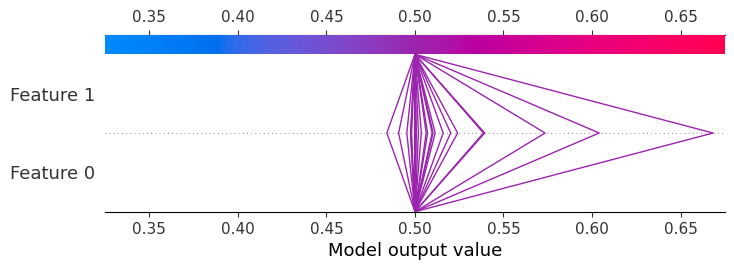

In [47]:
print(" SHAP Decision Plot")

# Sample data (keep small)
X_sample = X_test_df.iloc[:100]

# Recompute SHAP values safely (full set)
shap_values_full = explainer.shap_values(X_sample, check_additivity=False)

#  Select class 1 (Malicious)
sv_fixed = shap_values_full[1]

#  Fix expected value (match class 1)
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1]

# Final decision plot
shap.decision_plot(
    expected_value,
    sv_fixed,
    X_sample.values
)

# **DEEP LEARNING**

#**`TRAIN-TEST FOR DEEP LEARNING`**

In [33]:
X_train_dl = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_dl = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# **`lstm_model`**

In [34]:
lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(X_train_dl.shape[1], 1)))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

lstm_model.fit(X_train_dl, y_train, epochs=5, batch_size=32)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1605/1605 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9533 - loss: 0.1216
Epoch 2/5
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9921 - loss: 0.0269
Epoch 3/5
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.9948 - loss: 0.0190
Epoch 4/5
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9955 - loss: 0.0166
Epoch 5/5
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9961 - loss: 0.0138


# **`LSTM RESULTS`**

In [35]:
lstm_probs = lstm_model.predict(X_test_dl)
lstm_pred = (lstm_probs > 0.5).astype(int)

print("========== LSTM RESULTS ==========\n")

print(" LSTM Performance")

# Metrics
metrics = evaluate(y_test, lstm_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

# Classification Report
print("\n LSTM Classification Report:\n")
print(classification_report(
    y_test,
    lstm_pred,
    target_names=["Normal", "Malicious"],
    digits=4
))

print("--------------------------------------------------\n")

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
========== LSTM RESULTS ==========

🔹 LSTM Performance
Accuracy: 0.9966
Precision: 0.9965
Recall: 0.9950
F1 Score: 0.9958

 LSTM Classification Report:

              precision    recall  f1-score   support

      Normal     0.9966    0.9976    0.9971      7613
   Malicious     0.9965    0.9950    0.9958      5222

    accuracy                         0.9966     12835
   macro avg     0.9966    0.9963    0.9964     12835
weighted avg     0.9966    0.9966    0.9966     12835

--------------------------------------------------



# **`CONFUSION MATRIX OF LSTM Model`**

<Figure size 640x480 with 0 Axes>

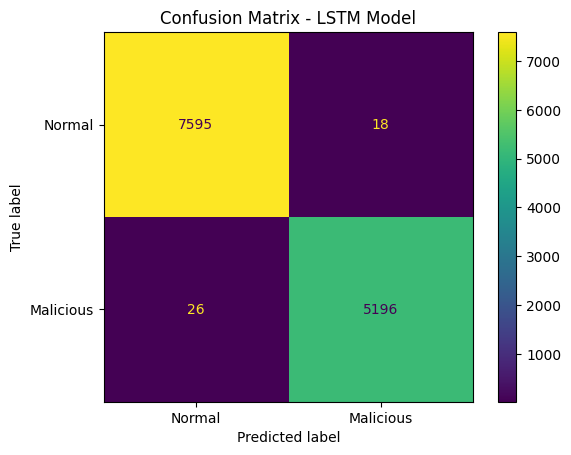

In [36]:
cm_lstm = confusion_matrix(y_test, lstm_pred)

# Display
disp_lstm = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["Normal", "Malicious"]
)

plt.figure()
disp_lstm.plot()
plt.title("Confusion Matrix - LSTM Model")
plt.show()

# **`HYBRID MODEL PERFORMANCE`**

In [37]:
input_layer = Input(shape=(X_train_dl.shape[1], 1))

lstm_out = LSTM(64, return_sequences=True)(input_layer)

attention = MultiHeadAttention(num_heads=2, key_dim=64)(lstm_out, lstm_out)
attention = LayerNormalization()(attention + lstm_out)

pooling = GlobalAveragePooling1D()(attention)

output = Dense(1, activation='sigmoid')(pooling)

hybrid_model = Model(inputs=input_layer, outputs=output)
hybrid_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hybrid_model.fit(
    X_train_dl,
    y_train,
    epochs=5,
    batch_size=32
)
hybrid_probs = hybrid_model.predict(X_test_dl)
hybrid_pred = (hybrid_probs > 0.5).astype(int)

# fix shape
hybrid_pred = hybrid_pred.flatten()
print("\n========== HYBRID MODEL RESULTS ==========\n")

print(" Hybrid Model Performance")

metrics = evaluate(y_test, hybrid_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

Epoch 1/5
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9539 - loss: 0.1199
Epoch 2/5
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9902 - loss: 0.0332
Epoch 3/5
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9934 - loss: 0.0247
Epoch 4/5
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9944 - loss: 0.0212
Epoch 5/5
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.9951 - loss: 0.0181
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step

========== HYBRID MODEL RESULTS ==========

🔹 Hybrid Model Performance
Accuracy: 0.9953
Precision: 0.9914
Recall: 0.9971
F1 Score: 0.9943


In [38]:
print("\n Hybrid Model Classification Report:\n")
print(classification_report(
    y_test,
    hybrid_pred,
    target_names=["Normal", "Malicious"],
    digits=4
))


 Hybrid Model Classification Report:

              precision    recall  f1-score   support

      Normal     0.9980    0.9941    0.9961      7613
   Malicious     0.9914    0.9971    0.9943      5222

    accuracy                         0.9953     12835
   macro avg     0.9947    0.9956    0.9952     12835
weighted avg     0.9953    0.9953    0.9953     12835



# **`CONFUSION MATRIX OF HYBRID MODEL`**

<Figure size 640x480 with 0 Axes>

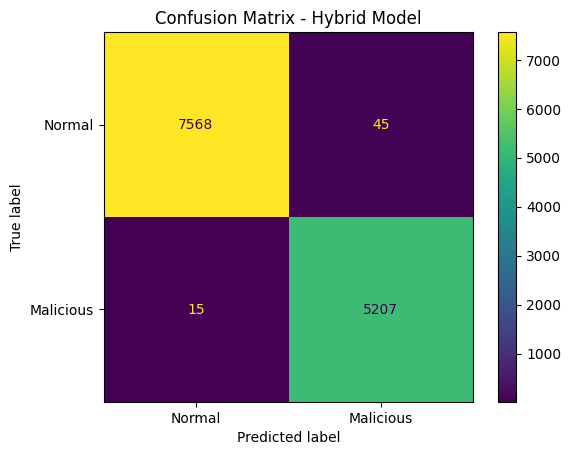

In [39]:
cm_hybrid = confusion_matrix(y_test, hybrid_pred)

# Display
disp_hybrid = ConfusionMatrixDisplay(
    confusion_matrix=cm_hybrid,
    display_labels=["Normal", "Malicious"]
)

plt.figure()
disp_hybrid.plot()
plt.title("Confusion Matrix - Hybrid Model")
plt.show()

# **`MODEL COMPRESION`**

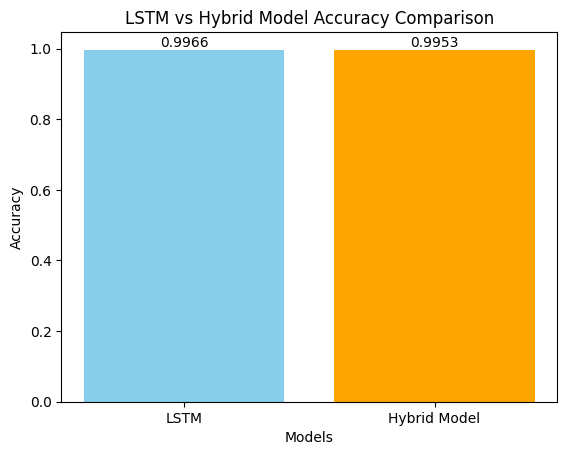

In [40]:
# Model names
models = ['LSTM', 'Hybrid Model']

# Accuracy values (dynamic, not hardcoded)
accuracy = [
    accuracy_score(y_test, lstm_pred),
    accuracy_score(y_test, hybrid_pred)
]

# Plot
plt.figure()
bars = plt.bar(models, accuracy, color=['skyblue', 'orange'])

plt.title("LSTM vs Hybrid Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Add values on top of bars (DYNAMIC)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha='center',
        va='bottom'
    )

plt.show()

# **SAVE THE MODEL FURTHER USE FOR WEB APPLICATION**

In [70]:
import pickle

# Save Random Forest model
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)